# Credit Card Consumption Prediction

This project analyzes customer behavior and demographic variables to predict credit card consumption (`cc_cons`). The workflow uses three customer-related Excel datasets, performs preprocessing, and compares several regression models using RMSPE as the evaluation metric.

## Project objective

The goal is to estimate `cc_cons` from customer-level features while keeping the analysis transparent and reproducible.

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [4]:
repo_root = Path.cwd()
candidate_dirs = [repo_root, repo_root.parent, repo_root / 'data', repo_root.parent / 'data']
data_dir = next((d for d in candidate_dirs if d.exists() and d.is_dir() and (d / 'CreditConsumptionData.xlsx').exists()), None)

if data_dir is None:
    raise FileNotFoundError('Add the Excel files to the data/ folder before running this notebook.')

data_dir

WindowsPath('c:/Users/Aditya singh/Desktop/Analytix/ML_project/Credit_card_prediction/data')

## 1. Load the datasets

The project uses three customer datasets that are merged on the `ID` column: consumption, behavior, and demographics.

In [5]:
cust_consup = pd.read_excel(data_dir / 'CreditConsumptionData.xlsx')
cust_behave = pd.read_excel(data_dir / 'CustomerBehaviorData.xlsx')
cust_demog = pd.read_excel(data_dir / 'CustomerDemographics.xlsx')

print('cust_consup shape:', cust_consup.shape)
print('cust_behave shape:', cust_behave.shape)
print('cust_demog shape:', cust_demog.shape)

cust_consup shape: (20000, 2)
cust_behave shape: (20000, 39)
cust_demog shape: (20000, 10)


In [6]:
cust_consup.info()
cust_behave.info()
cust_demog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       20000 non-null  int64  
 1   cc_cons  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 312.6 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     20000 non-null  int64  
 1   cc_cons_apr            20000 non-null  float64
 2   dc_cons_apr            20000 non-null  float64
 3   cc_cons_may            19999 non-null  float64
 4   dc_cons_may            19999 non-null  float64
 5   cc_cons_jun            20000 non-null  float64
 6   dc_cons_jun            19999 non-null  float64
 7   cc_count_apr           19999 non-null  float64
 8   cc_count_may           20000 non-null  int64  
 9   cc

## 2. Missing values

The notebook handles missing values using a practical, column-specific strategy: median for numeric values and mode for selected categorical and flag-like features.

In [7]:
cust_demog[['account_type', 'gender', 'Income']] = cust_demog[['account_type', 'gender', 'Income']].replace(0, np.nan)
cust_demog[['account_type', 'gender', 'Income']] = cust_demog[['account_type', 'gender', 'Income']].fillna(
    cust_demog[['account_type', 'gender', 'Income']].mode().iloc[0]
)

cols_median = ['cc_cons_may', 'dc_cons_may', 'investment_3', 'dc_cons_jun', 'cc_count_apr']
cols_mode = ['personal_loan_closed', 'debit_count_apr', 'loan_enq', 'emi_active']

cust_behave[cols_median] = cust_behave[cols_median].fillna(cust_behave[cols_median].median())
cust_behave[cols_mode] = cust_behave[cols_mode].fillna(cust_behave[cols_mode].mode().iloc[0])

print('Nulls in behavior data:', cust_behave.isnull().sum().sum())
print('Nulls in demographics data:', cust_demog.isnull().sum().sum())
print('Nulls in consumption data:', cust_consup.isnull().sum().sum())

Nulls in behavior data: 0
Nulls in demographics data: 0
Nulls in consumption data: 5000


## 3. Outlier handling

Extreme values are clipped using an IQR-based rule to reduce skew and protect the model against highly influential observations.

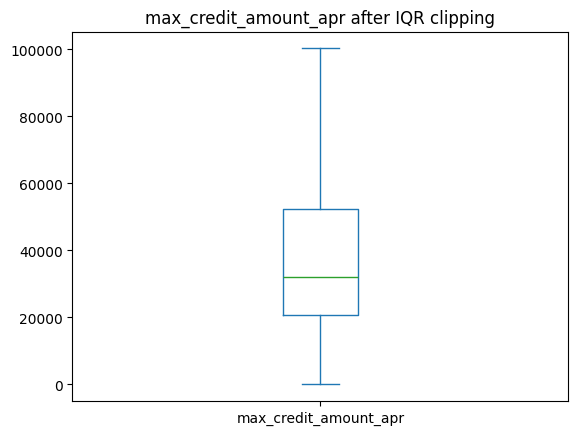

In [8]:
def clip_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    return series.clip(lower=lower_limit, upper=upper_limit)

behave_cols = cust_behave.drop(['ID', 'personal_loan_active', 'vehicle_loan_active', 'personal_loan_closed', 'vehicle_loan_closed', 'loan_enq'], axis=1).columns
demo_cols = cust_demog.select_dtypes(include='number').drop(['ID', 'Avg_days_between_transaction'], axis=1).columns

cust_behave[behave_cols] = cust_behave[behave_cols].apply(clip_outliers)
cust_demog[demo_cols] = cust_demog[demo_cols].apply(clip_outliers)

cust_behave['max_credit_amount_apr'].plot(kind='box')
plt.title('max_credit_amount_apr after IQR clipping')
plt.show()

## 4. Merge and feature engineering

The three tables are merged on the customer `ID`, and categorical columns are converted to dummy variables so the models can use them.

In [9]:
cust_data = cust_consup.merge(cust_behave, how='inner', on='ID').merge(cust_demog, how='inner', on='ID')
cust_data = cust_data.drop(['personal_loan_active', 'vehicle_loan_active', 'personal_loan_closed', 'vehicle_loan_closed', 'Tenure_with_Bank'], axis=1, errors='ignore')

cat_cols = cust_data.select_dtypes(include='object').columns
if len(cat_cols) > 0:
    cust_data = pd.get_dummies(cust_data, columns=cat_cols, drop_first=True)

cust_data = cust_data.replace({True: 1, False: 0})
print('Merged dataset shape:', cust_data.shape)
print('Final number of columns:', len(cust_data.columns))

Merged dataset shape: (20000, 44)
Final number of columns: 44


C:\Users\Aditya singh\AppData\Local\Temp\ipykernel_30168\3880171517.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cust_data = cust_data.replace({True: 1, False: 0})


## 5. Train/test split

Rows without a target value are retained for later prediction, while rows with `cc_cons` are used to train and evaluate the supervised models.

In [10]:
actual_data = cust_data.loc[~cust_data['cc_cons'].isnull()].copy()
prediction_data = cust_data.loc[cust_data['cc_cons'].isnull()].copy()

X = actual_data.drop(['ID', 'cc_cons'], axis=1)
y = actual_data['cc_cons']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train rows:', len(X_train))
print('Test rows:', len(X_test))

Train rows: 12000
Test rows: 3000


## VIF check

A variance inflation factor check is included to flag multicollinearity before the final model comparison. This helps assess whether a feature subset is more stable for the regression workflow.

In [15]:
vif_df = pd.DataFrame({
    'Features': X_train.columns,
    'VIF': [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
})

vif_df = vif_df.sort_values(by='VIF', ascending=True)
vif_df.head(10)

features_vif = vif_df.loc[vif_df['VIF'] < 5, 'Features']
X_train_vif = X_train[features_vif]
X_test_vif = X_test[features_vif]

scaler_vif = StandardScaler()
X_train_vif_scaled = scaler_vif.fit_transform(X_train_vif)
X_test_vif_scaled = scaler_vif.transform(X_test_vif)

knn_vif_best = KNeighborsRegressor(n_neighbors=9, weights='distance')
knn_vif_best.fit(X_train_vif_scaled, y_train)

vif_train_rmspe = np.sqrt(np.mean(((y_train - knn_vif_best.predict(X_train_vif_scaled)) / y_train) ** 2)) * 100
vif_test_rmspe = np.sqrt(np.mean(((y_test - knn_vif_best.predict(X_test_vif_scaled)) / y_test) ** 2)) * 100

print(f'VIF-filtered KNN train RMSPE: {vif_train_rmspe:.2f}%')
print(f'VIF-filtered KNN test RMSPE: {vif_test_rmspe:.2f}%')

VIF-filtered KNN train RMSPE: 0.00%
VIF-filtered KNN test RMSPE: 55.23%


## 6. Model comparison

The project compares Linear Regression, KNN, and Decision Tree models using RMSPE, a percentage-based error metric appropriate for this regression task.

In [ ]:
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2)) * 100

def evaluate_model(model, X_train_model, y_train_model, X_test_model, y_test_model):
    model.fit(X_train_model, y_train_model)
    train_pred = model.predict(X_train_model)
    test_pred = model.predict(X_test_model)
    return {
        "train_rmspe": rmspe(y_train_model, train_pred),
        "test_rmspe": rmspe(y_test_model, test_pred)
    }

results = []
results.append(("Linear Regression", evaluate_model(LinearRegression(), X_train_scaled, y_train, X_test_scaled, y_test)))
results.append(("KNN", evaluate_model(KNeighborsRegressor(n_neighbors=10), X_train_scaled, y_train, X_test_scaled, y_test)))
results.append(("Decision Tree", evaluate_model(DecisionTreeRegressor(max_depth=6, random_state=12), X_train_scaled, y_train, X_test_scaled, y_test)))

for name, score in results:
    print(f"{name} - train RMSPE: {score['train_rmspe']:.2f}% | test RMSPE: {score['test_rmspe']:.2f}%")

Linear Regression - train RMSPE: 40.81% | test RMSPE: 40.89%
KNN - train RMSPE: 52.72% | test RMSPE: 56.37%
Decision Tree - train RMSPE: 62.66% | test RMSPE: 66.69%


## 7. Model tuning

The notebook also explores GridSearchCV for parameter tuning on KNN and the Decision Tree, which gives a clearer view of how model choice affects performance.

In [14]:
dtr_params = {
    'max_depth': [4, 5, 6, 7, 8, 9, 10, 12, 15, 30],
    'max_features': [2, 3, 4, 5, 6, 7, 10, 12, 15],
    'max_leaf_nodes': [2, 3, 4, 5, 6, 7]
}

dtr_gridCV = GridSearchCV(DecisionTreeRegressor(random_state=12), param_grid=dtr_params, cv=5)
dtr_gridCV.fit(X_train_scaled, y_train)
print('Best DTR params:', dtr_gridCV.best_params_)

best_dtr = DecisionTreeRegressor(
    max_depth=8,
    max_features=7,
    max_leaf_nodes=5,
    random_state=12
)
best_dtr.fit(X_train_scaled, y_train)

best_train_rmspe = np.sqrt(np.mean(((y_train - best_dtr.predict(X_train_scaled)) / y_train) ** 2)) * 100
best_test_rmspe = np.sqrt(np.mean(((y_test - best_dtr.predict(X_test_scaled)) / y_test) ** 2)) * 100

print(f'Best tuned DTR train RMSPE: {best_train_rmspe:.2f}%')
print(f'Best tuned DTR test RMSPE: {best_test_rmspe:.2f}%')

Best DTR params: {'max_depth': 6, 'max_features': 15, 'max_leaf_nodes': 7}
Best tuned DTR train RMSPE: 79.21%
Best tuned DTR test RMSPE: 74.46%


## 8. Key takeaways

This project demonstrates a realistic end-to-end regression workflow: data preparation, feature engineering, modeling, and evaluation. The notebook is intentionally kept notebook-first so the analytical story remains easy to follow for technical recruiters and hiring managers.